**ESTRUCTURA**

EXPLICAR PROBLEMA A SOLUCIONAR / INTRODUCCION 

IMPORTAR LIBRERIAS

DEFINIR EL PROBLEMA + EXPLICAR EL DATASET

CARGAR DATOS Y EXPLORATION INICIAL


DIVISON TRAIN Y TEST

MINI EDA - univariante, bivariante correlaciones, target

TRATAMIENTO DE FEATURES - eliminar features, nans, duplicados,  anomalías, outliers, transformaciones, encodings, escalado, feature engineering

ELECCION DE METRICAS

SELECCION DEL MODELO / BASELINE Y COMPARATIVA

ENTRENAMIENTO DEL MODELO

REGULARIZACION HIPERPARAMETRIZACION / OPTIMIZACION DE HIPERPARAMETROS

EVALUACION SOBRE TEST

PERSISTENCIA DEL MODELO

CONCLUSION

>**TIMETABLE**

| ACTIVITY | DONE? |
|---|---|
| EXPLICAR PROBLEMA A SOLUCIONAR / INTRODUCCION |  NO  |
| IMPORTAR LIBRERIAS |  DONE  |
| DEFINIR EL PROBLEMA + EXPLICAR EL DATASET |  NO  |
| CARGAR DATOS Y EXPLORATION INICIAL |  DONE  |
| DIVISON TRAIN Y TEST |  DONE  |
| MINI EDA |  DONE  |
| TRATAMIENTO DE FEATURES |  DONE  |
| ELECCION DE METRICAS |  DONE  |
| SELECCION DEL MODELO / BASELINE Y COMPARATIVA |  IN PROGRESS  |
| ENTRENAMIENTO DEL MODELO |  NO  |
REGULARIZACION HIPERPARAMETRIZACION / OPTIMIZACION DE HIPERPARAMETROS |  NO  |
EVALUACION SOBRE TEST |  NO  |
PERSISTENCIA DEL MODELO |  NO  |
CONCLUSION |  NO  |

**QUE VOY A PREDECIR**:

Operating Profit: el dinero que gana la empresa después de pagar los costes del negocio, pero antes de impuestos e intereses.

**IMPORTAR LIBRERÍAS**

In [ ]:
import pandas as pd
import numpy as np
pd.options.mode.copy_on_write = True


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.metrics import make_scorer


import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración global
sns.set_style('whitegrid')
SEED = 42
print(' Librerías importadas correctamente')

**CARGA DE DATOS Y EXPLORACIÓN INICIAL**

In [ ]:
df_adidas = pd.read_excel("./data/Adidas_US_Sales_Datasets.xlsx", header=4)

In [ ]:
df_adidas.head(10)

In [4]:
df_adidas.columns

Index(['Unnamed: 0', 'Retailer', 'Retailer ID', 'Invoice Date', 'Region',
       'State', 'City', 'Product', 'Price per Unit', 'Units Sold',
       'Total Sales', 'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')

In [5]:
df_adidas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Unnamed: 0        0 non-null      float64       
 1   Retailer          9648 non-null   object        
 2   Retailer ID       9648 non-null   int64         
 3   Invoice Date      9648 non-null   datetime64[ns]
 4   Region            9648 non-null   object        
 5   State             9648 non-null   object        
 6   City              9648 non-null   object        
 7   Product           9648 non-null   object        
 8   Price per Unit    9648 non-null   float64       
 9   Units Sold        9648 non-null   int64         
 10  Total Sales       9648 non-null   float64       
 11  Operating Profit  9648 non-null   float64       
 12  Operating Margin  9648 non-null   float64       
 13  Sales Method      9648 non-null   object        
dtypes: datetime64[ns](1), fl

In [6]:
df_adidas.describe()

,Unnamed: 0,Retailer ID,Invoice Date,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,0.0,9.648000e+03,9648,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,NaN,1.173850e+06,2021-05-10 15:20:44.776119296,45.216625,256.930037,93273.437500,34425.244761,0.422991
min,NaN,1.128299e+06,2020-01-01 00:00:00,7.000000,0.000000,0.000000,0.000000,0.100000
25%,NaN,1.185732e+06,2021-02-17 00:00:00,35.000000,106.000000,4254.500000,1921.752500,0.350000
50%,NaN,1.185732e+06,2021-06-04 00:00:00,45.000000,176.000000,9576.000000,4371.420000,0.410000
75%,NaN,1.185732e+06,2021-09-16 00:00:00,55.000000,350.000000,150000.000000,52062.500000,0.490000
max,NaN,1.197831e+06,2021-12-31 00:00:00,110.000000,1275.000000,825000.000000,390000.000000,0.800000
std,NaN,2.636038e+04,NaN,14.705397,214.252030,141916.016727,54193.113713,0.097197


Eliminamos la columna Unnamed porque no aprota nada

In [ ]:
df_adidas.drop("Unnamed: 0", axis=1, inplace=True)

In [60]:
df_adidas.columns

Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')

**3. LIMPIEZA DE DATOS**

Valores faltantes:

In [ ]:
print(df_adidas.isna().sum())

Revisar duplicados:

In [ ]:
df_adidas = df_adidas.drop_duplicates()

Tipos de datos:

In [ ]:
print(df_adidas.dtypes)

**4. MINI EDA**

**pairplot**

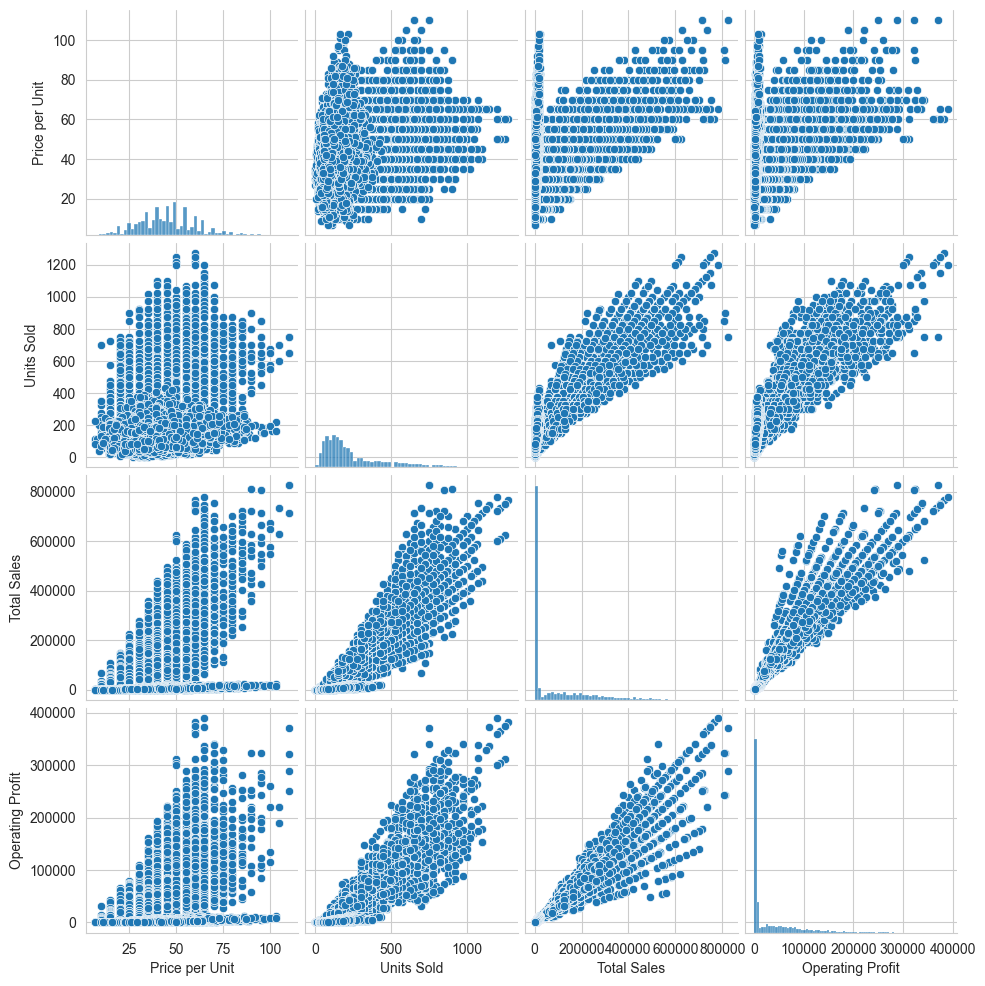

In [15]:
num_cols = ["Price per Unit", "Units Sold", "Total Sales", "Operating Profit"]
sns.pairplot(df_adidas[num_cols])
plt.show()

**Estudio del target**

<Axes: xlabel='Operating Profit', ylabel='Count'>

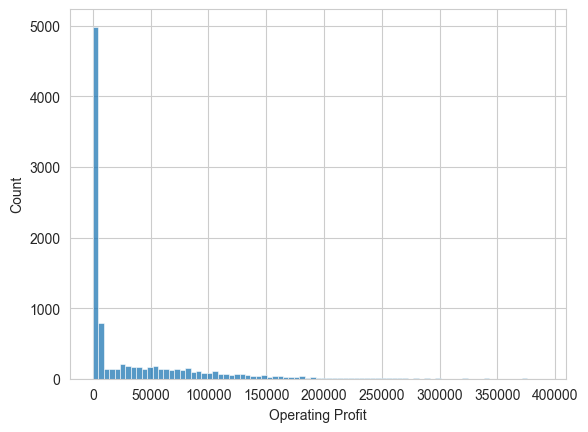

In [16]:
sns.histplot(df_adidas['Operating Profit'])

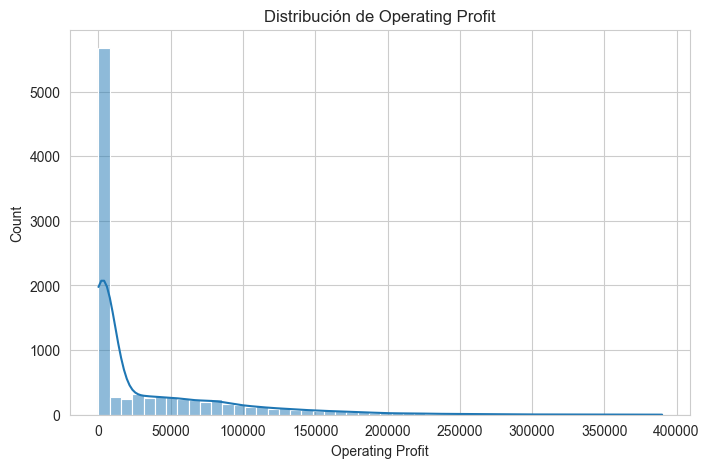

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df_adidas["Operating Profit"], bins=50, kde=True)
plt.title("Distribución de Operating Profit")
plt.show()

Boxplot

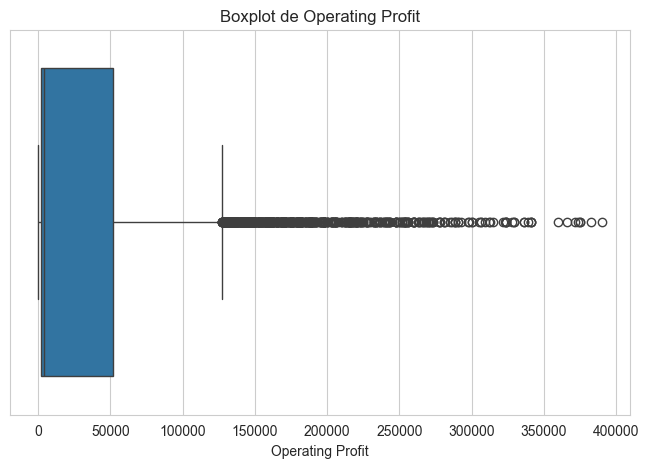

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_adidas["Operating Profit"])
plt.title("Boxplot de Operating Profit")
plt.show()

In [19]:
df_adidas["Operating Profit"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

count      9648.000000
mean      34425.244761
std       54193.113713
min           0.000000
1%          344.862600
25%        1921.752500
50%        4371.420000
75%       52062.500000
99%      242647.500000
max      390000.000000
Name: Operating Profit, dtype: float64

**Correlaciones**

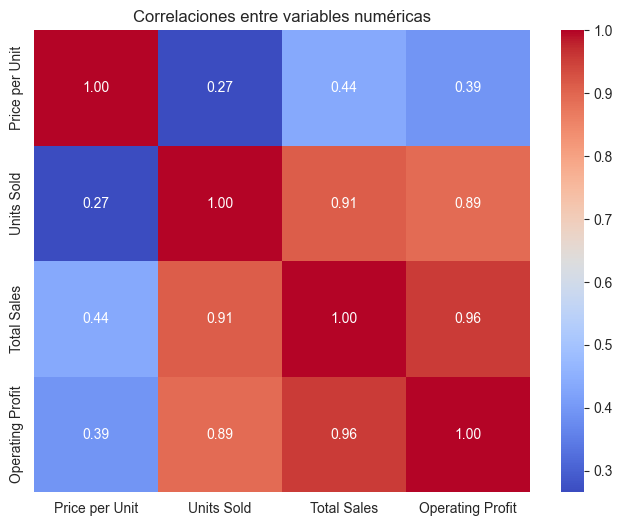

In [20]:
corr = df_adidas[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlaciones entre variables numéricas")
plt.show()

**Análisis univariante**

Numéricas:

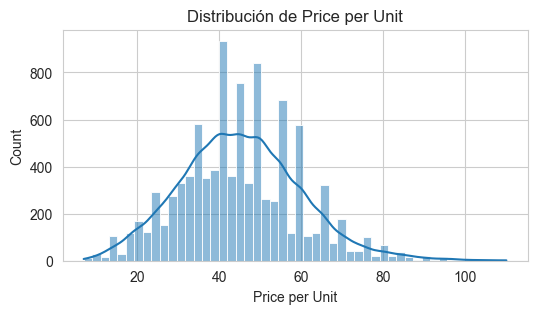

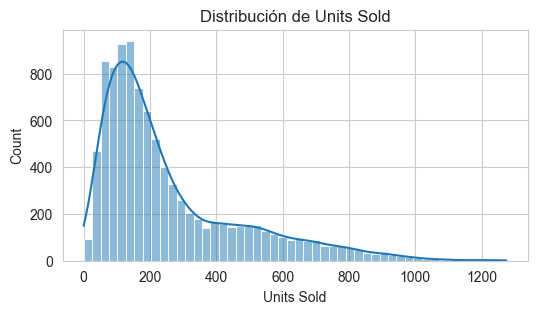

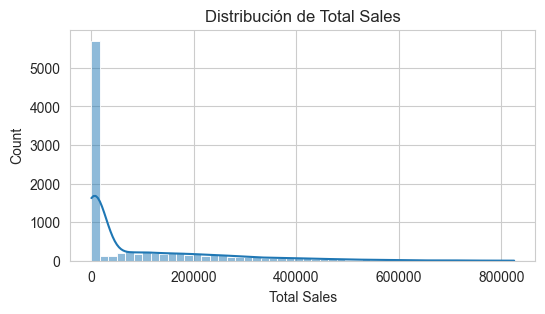

In [21]:
for col in ["Price per Unit", "Units Sold", "Total Sales"]:
    plt.figure(figsize=(6,3))
    sns.histplot(df_adidas[col], bins=50, kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

Categóricas:

In [22]:
categorical_cols = ["Region", "Product", "Sales Method"]
for col in categorical_cols:
    print(df_adidas[col].value_counts())

Region
West         2448
Northeast    2376
Midwest      1872
South        1728
Southeast    1224
Name: count, dtype: int64
Product
Men's Street Footwear        1610
Men's Athletic Footwear      1610
Women's Street Footwear      1608
Women's Apparel              1608
Women's Athletic Footwear    1606
Men's Apparel                1606
Name: count, dtype: int64
Sales Method
Online      4889
Outlet      3019
In-store    1740
Name: count, dtype: int64


array([[<Axes: title={'center': 'Retailer ID'}>,
        <Axes: title={'center': 'Invoice Date'}>,
        <Axes: title={'center': 'Price per Unit'}>],
       [<Axes: title={'center': 'Units Sold'}>,
        <Axes: title={'center': 'Total Sales'}>,
        <Axes: title={'center': 'Operating Profit'}>],
       [<Axes: title={'center': 'Operating Margin'}>, <Axes: >, <Axes: >]],
      dtype=object)

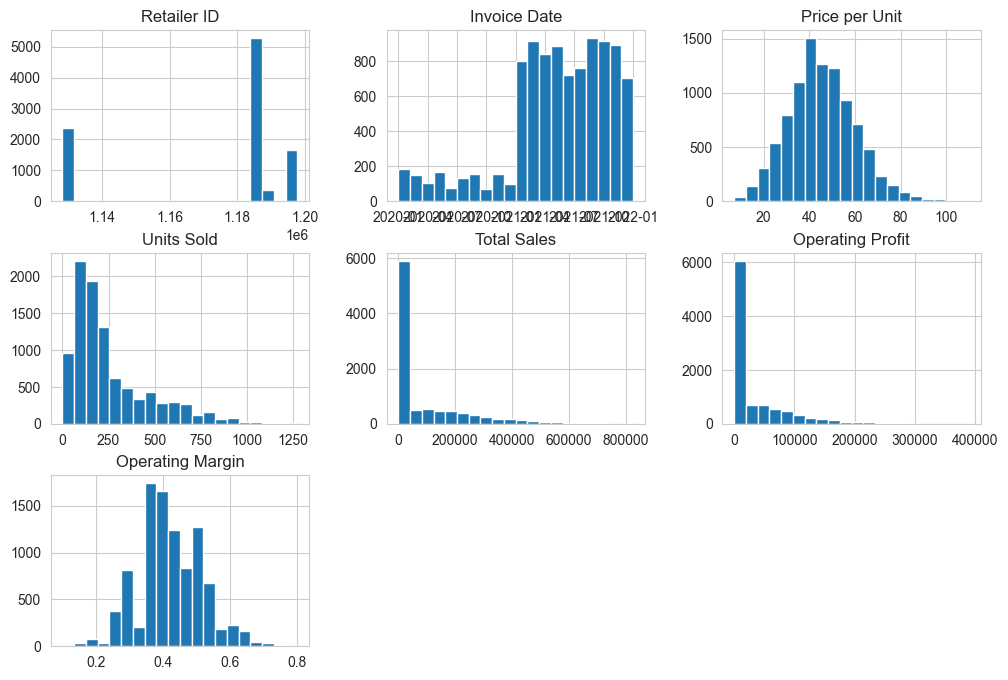

In [46]:
df_adidas.hist(figsize=(12,8), bins=20)

**Análisis bivariante**

Relación entre Operating Profit y variables numéricas

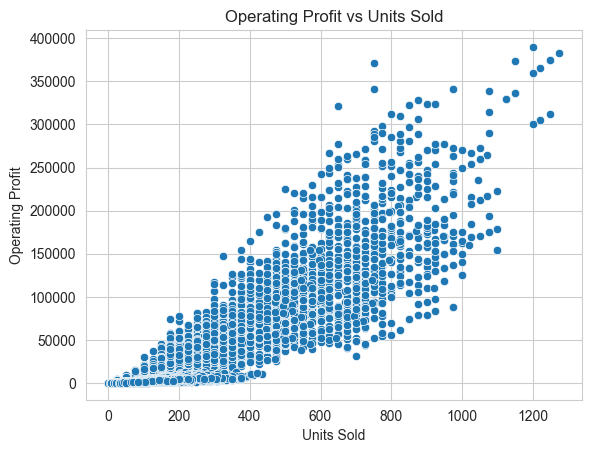

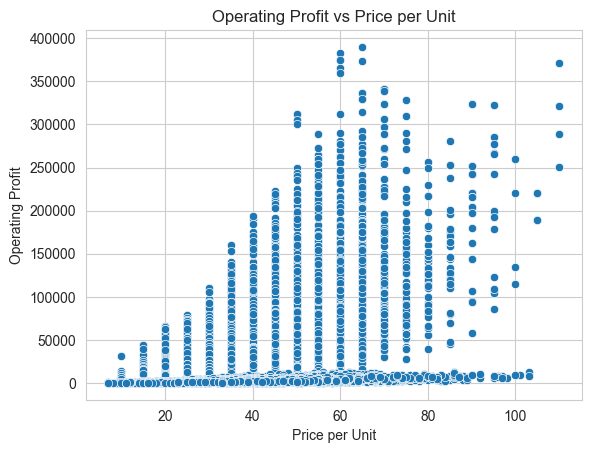

In [23]:
sns.scatterplot(x="Units Sold", y="Operating Profit", data=df_adidas)
plt.title("Operating Profit vs Units Sold")
plt.show()

sns.scatterplot(x="Price per Unit", y="Operating Profit", data=df_adidas)
plt.title("Operating Profit vs Price per Unit")
plt.show()

Relación con categóricas (boxplots):

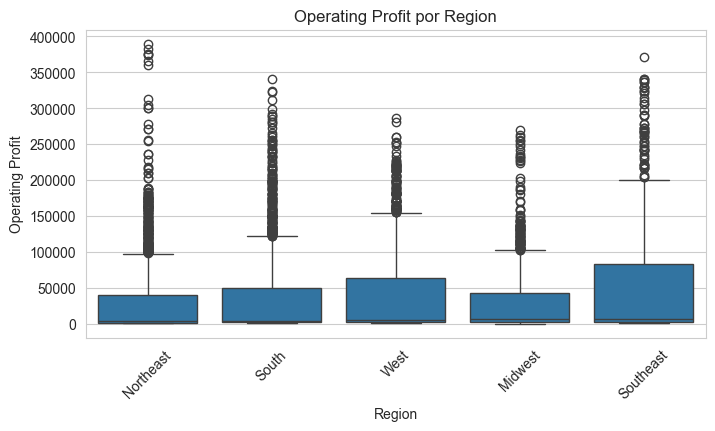

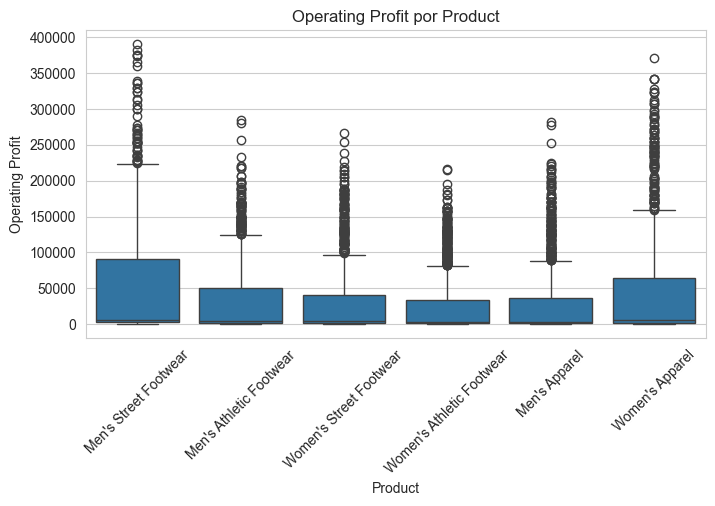

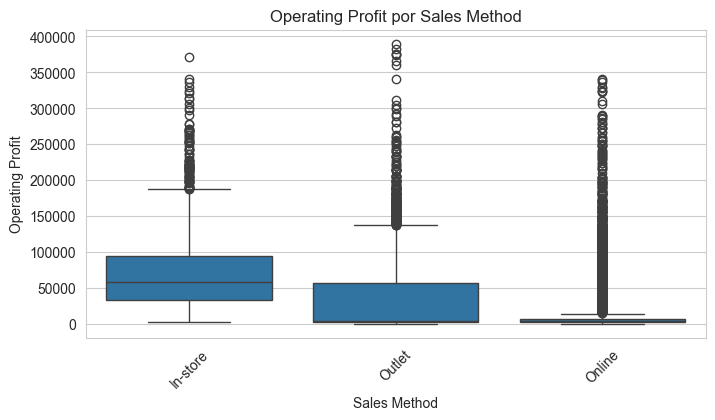

In [24]:
for col in ["Region", "Product", "Sales Method"]:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y="Operating Profit", data=df_adidas)
    plt.title(f"Operating Profit por {col}")
    plt.xticks(rotation=45)
    plt.show()

**5. TRATAMIENTO DE VARIABLES**

**Eliminacion de features**

In [ ]:
df_adidas = df_adidas.drop(columns=["Operating Margin", "Total Sales"])

In [ ]:
df_adidas = df_adidas.drop("Invoice Date", axis=1)

**Eliminar duplicados**

In [ ]:
df_adidas = df_adidas.drop_duplicates()

**Anomalias y errores**

In [ ]:
upper_limit = df_adidas["Operating Profit"].quantile(0.99)
df_adidas = df_adidas[df_adidas["Operating Profit"] <= upper_limit]

**Outliers**

In [ ]:
num_cols = ["Price per Unit", "Units Sold"]
for col in num_cols:
    q1 = df_adidas[col].quantile(0.25)
    q3 = df_adidas[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    df_adidas = df_adidas[(df_adidas[col] >= lower) & (df_adidas[col] <= upper)]

**Transformaciones**

In [ ]:
df_adidas["year"] = df_adidas["Invoice Date"].dt.year
df_adidas["month"] = df_adidas["Invoice Date"].dt.month
df_adidas = df_adidas.drop("Invoice Date", axis=1)

In [ ]:
X.dtypes.value_counts()

**Encodigns**

In [ ]:
categorical_cols = ["Retailer", "Region", "State", "City", "Product", "Sales Method"]

df_adidas = pd.get_dummies(df_adidas, columns=categorical_cols, drop_first=True)

**Escalado**

In [ ]:
scaler = StandardScaler()
num_cols = ["Price per Unit", "Units Sold", "year", "month"]
df_adidas[num_cols] = scaler.fit_transform(df_adidas[num_cols])

**6. FEATURE ENGINEERING**

In [ ]:
df_adidas["Price_x_Units"] = df_adidas["Price per Unit"] * df_adidas["Units Sold"]

In [ ]:
df_adidas["quarter"] = df_adidas["month"].apply(lambda x: (x-1)//3 + 1)
df_adidas["holiday_season"] = df_adidas["month"].apply(lambda x: 1 if x in [11,12] else 0)

**7. ELECCIÓN DE MÉTRICAS**

R² + RMSE

**DIVISON DE TRAIN Y TEST**

In [ ]:
X = df_adidas.drop("Operating Profit", axis=1)
y = df_adidas["Operating Profit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**8. SELECCIÓN DE MODELO**

**BASELINE - Regresión lineal**

In [ ]:
from sklearn.linear_model import LinearRegression

#Entrenamos
model = LinearRegression()
model.fit(X_train, y_train)


In [ ]:
#hacemos predicciones
y_pred = model.predict(X_test)

.

In [ ]:
# Evaluamos
from sklearn.metrics import r2_score, mean_squared_error


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("RMSE:", rmse)

In [ ]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model.coef_
}).sort_values(by="coef", ascending=False)

coef_df.head(10)

**ELIMINACIÓN DE DATA LEAKAGE**

En el dataset existen variables que contienen información directa sobre la variable objetivo (Operating Profit), lo que puede provocar leakage.

En concreto:
* Total Sales
* Operating Margin

Esto se debe a que:
* Operating Profit ≈ Total Sales × Operating Margin

Si dejamos estas variables en el modelo, este no estaría aprendiendo patrones reales, sino reconstruyendo una fórmula matemática, lo que produce métricas artificialmente altas (R² inflado).

Por tanto, eliminamos estas variables para construir un modelo más realista y generalizable.

In [ ]:
X = df_adidas.drop(["Operating Profit", "Total Sales", "Operating Margin"], axis=1)
y = df_adidas["Operating Profit"]

In [ ]:
# Dividimos nuevamente en train y test (ya sin data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenamos el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Hacemos predicciones
y_pred = model.predict(X_test)

# Evaluamos
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)

# Coeficientes del modelo
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model.coef_
}).sort_values(by="coef", ascending=False)

coef_df.head(10)


**Comparación con otros modelos**

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ---- MODELOS A EVALUAR ----
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# ---- ENTRENAMIENTO Y EVALUACION ----
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({"Model": name, "R2": r2, "RMSE": rmse})

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print(results_df)

RandomForest - R2: 0.9700, RMSE: 9510.38


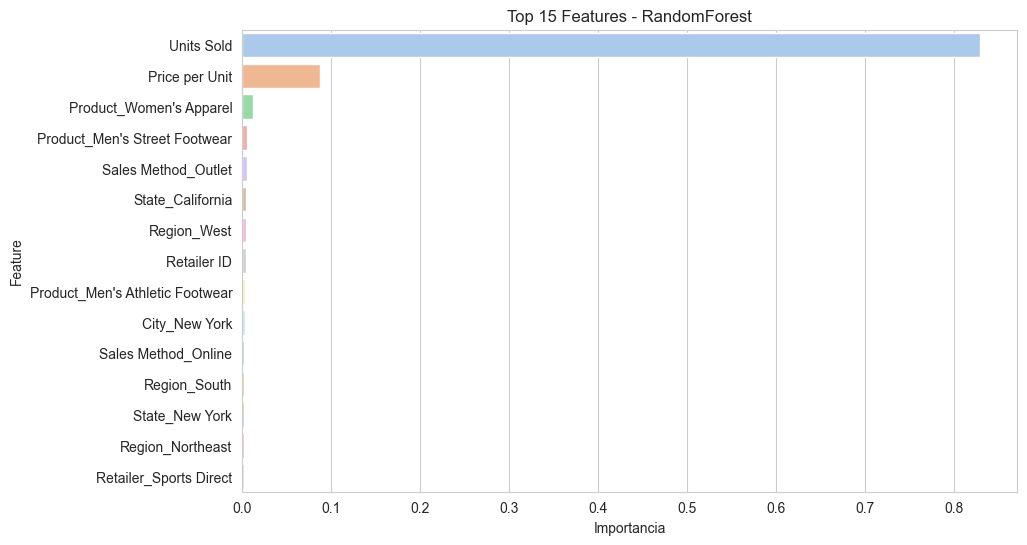

GradientBoosting - R2: 0.9435, RMSE: 13056.47


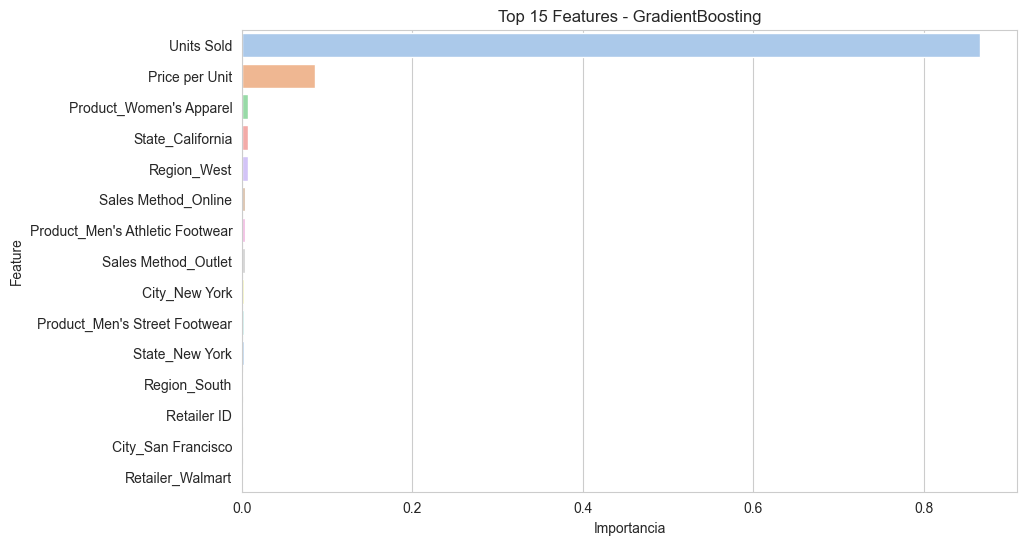

In [91]:
# ---- IMPORTANCIA DE VARIABLES PARA MODELOS DE ARBOL ----
tree_models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

for name, model in tree_models.items():
    # Entrenamiento
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Evaluación
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name} - R2: {r2:.4f}, RMSE: {rmse:.2f}")
    
    # Importancia de variables
    importances = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values(by="importance", ascending=False).head(15)  # top 15 features
    
    # Gráfico
    plt.figure(figsize=(10,6))
    sns.barplot(x="importance", y="feature", data=importances, palette="pastel")
    plt.title(f"Top 15 Features - {name}")
    plt.xlabel("Importancia")
    plt.ylabel("Feature")
    plt.show()

Escogemos **RANDOM FOREST**

**Optimización de Hiperparámetros**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


rf = RandomForestRegressor(random_state=42)


param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt", "log2"]
}


random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,           
    cv=5,                
    scoring="r2",        
    n_jobs=-1,         
    verbose=2,
    random_state=42
)


random_search.fit(X_train, y_train)

# Mejor combinación y mejor modelo
print("Mejores hiperparámetros:", random_search.best_params_)
best_rf = random_search.best_estimator_

In [ ]:
# Extraer importancia de features
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values(by="importance", ascending=False)

# Mostrar top 10
print(feature_importances.head(10))

# Gráfico
plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feature_importances.head(10), palette="pastel")
plt.title("Top 10 Features más importantes - Random Forest")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score


# Validación cruzada 5-fold
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)

print("R2 promedio CV:", np.mean(cv_scores))
print("R2 std CV:", np.std(cv_scores))

**Sobre test**

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Validación cruzada 5-fold
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)

print("R2 promedio CV:", np.mean(cv_scores))
print("R2 std CV:", np.std(cv_scores))

**Persistencia**

In [ ]:
import joblib

# Guardar
joblib.dump(best_rf, "best_random_forest.pkl")

# Cargar después!!!
# loaded_model = joblib.load("best_random_forest.pkl")